Normal Equation Weights (bias, slope): [1.43019232 2.40804535]
Gradient Descent Weights (bias, slope): [1.17189183 2.4477457 ]
Baseline MSE (guessing mean): 54.0315
Final GD MSE: 3.2453


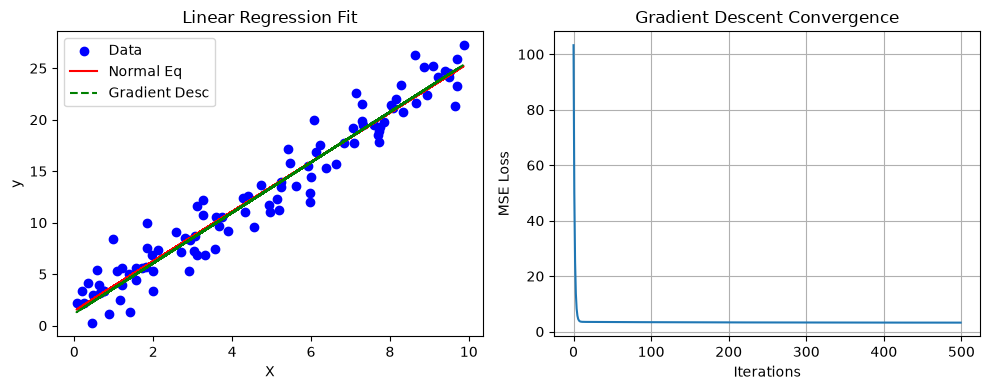

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. GENERATE SYNTHETIC DATA
# -------------------------------
np.random.seed(42)
m = 100  # samples
X = np.random.rand(m, 1) * 10  # single feature
true_w = 2.5
true_b = 1.0
y = true_w * X.flatten() + true_b + np.random.randn(m) * 2  # add noise

# Add intercept column (bias) to X
X_b = np.c_[np.ones((m, 1)), X]  # shape (100, 2)

# -------------------------------
# 2. BASIC LINEAR REGRESSION (Normal Equation)
# -------------------------------
w_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("Normal Equation Weights (bias, slope):", w_normal)

# -------------------------------
# 3. GRADIENT DESCENT IMPLEMENTATION
# -------------------------------
def compute_mse(X, y, weights):
    m = len(y)
    predictions = X @ weights
    return (1/m) * np.sum((predictions - y) ** 2)

def gradient_descent(X, y, alpha, iterations):
    m, n = X.shape
    weights = np.zeros(n)  # initialize to zero
    loss_history = []
    
    for i in range(iterations):
        predictions = X @ weights
        error = predictions - y
        gradient = (1/m) * (X.T @ error)
        weights = weights - alpha * gradient
        loss_history.append(compute_mse(X, y, weights))
    
    return weights, loss_history

# Train using Gradient Descent
alpha = 0.01
iterations = 500
w_gd, loss_hist = gradient_descent(X_b, y, alpha, iterations)

print("Gradient Descent Weights (bias, slope):", w_gd)

# -------------------------------
# 4. BASELINE (MEAN PREDICTOR)
# -------------------------------
mean_y = np.mean(y)
baseline_predictions = np.full_like(y, mean_y)
baseline_mse = (1/len(y)) * np.sum((baseline_predictions - y) ** 2)
print(f"Baseline MSE (guessing mean): {baseline_mse:.4f}")
print(f"Final GD MSE: {loss_hist[-1]:.4f}")

# -------------------------------
# 5. PLOT RESULTS
# -------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, X_b @ w_normal, color='red', label='Normal Eq')
plt.plot(X, X_b @ w_gd, '--', color='green', label='Gradient Desc')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression Fit')

plt.subplot(1, 2, 2)
plt.plot(range(iterations), loss_hist)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.grid(True)

plt.tight_layout()
plt.show()